# Prosperity Rating — How It Works

**RRsystem / notebooks/prosperity_rating_explained.ipynb**

Seasonal asks *"how are you doing in this window?"* Overall asks *"how strong are you, full stop?"*

Prosperity asks a question neither can answer: **"which way are you going — and is there enough
signal to say?"**

That makes it a different kind of object from the first two, in four ways that drive every decision below:

| | Seasonal / Overall | Prosperity |
|---|---|---|
| What it measures | a **level** | a **derivative** — direction over a window |
| How it updates | incrementally, per match, zero-sum | **recomputed for the whole field** at once |
| Scale | absolute — 1500 means the same thing every year | **cohort-relative** — a position within a field |
| Source table | `match_events` | `overall_rating_events` — it is a *query*, not a new Elo |

---

## The constraint this notebook works under

The prototype in `four_dimensional_elo_ratings.ipynb` defines prosperity as

```python
delta = 35.0 * tanh(rating_change / 100.0) + 20.0 * knowledge_transfer - 10.0 * volatility
```

and then says, correctly, that "without reliable observations of strategy, learning, knowledge
transfer, and outcomes after changes, these scores can become arbitrary."

That is the problem to solve, not a footnote. `knowledge_transfer` is not a column anyone logs. A
rating that needs a human to hand-label a float per participant per period will not be maintained,
and an unmaintained rating is noise with a 1500 baseline attached.

> **Prosperity must be computable from `overall_rating_events` alone — no new metadata, no hand labels.**

## What this notebook found

The plan was a three-component weighted composite: direction, control, durability. **The
measurements did not support it.** Sections 9–11 show the evidence instead of quietly reweighting:

| Candidate | Split-half reliability | Verdict |
|---|---|---|
| **Trajectory** — robust slope over the window | ≈ +1.00 | **the rating** (validity ρ ≈ +0.6, range 0.42–0.79) |
| **Coherence** — how directed the path was | ≈ +1.00 | **a confidence**, not a virtue |
| **Dispersion** — erratic vs model expectation | ≈ **0** | **a flag**; valid (ρ ≈ +0.7 vs truth) but far too noisy to rank on |
| Retention — "were gains held" | ≈ +1.00 | **dropped**: ρ ≈ +0.6 with trajectory, and no ground truth for the rest |

The central result is section 10, and it is *not* the one the first draft of this notebook claimed.
Coherence does **not** make the trajectory estimate more accurate — mean absolute error is
essentially identical in both halves of the field. What it does is identify **who has a real trend
at all**. Averaged over independent seeds, the trajectory recovers true development at ρ ≈ **+0.73**
among coherent paths and ρ ≈ **+0.20** among incoherent ones — because those players have almost no
directional signal to rank in the first place.

So prosperity is a trajectory **shrunk toward neutral in proportion to how much signal there is**,
which is a claim about *signal-to-noise*, not about accuracy.

Three traps make a naive version worse than useless, all measured here rather than asserted:

- **Section 5** — most apparent "improvement" is **convergence from 1500**, so a naive improvement
  score ranks by *strength*, which the overall rating already told you.
- **Section 6** — raw volatility is dominated by **K**, which falls with experience. Rank on it and
  you have ranked beginners as chaotic by construction.
- **Section 7** — Elo is **zero-sum**. Nobody rises unless someone falls, so a trajectory measures
  movement *relative to the field*, never absolute development.

And one methodological trap that caught this notebook itself: **section 13**. Every correlation
above is a rank correlation over a few dozen players, which is a *noisy* statistic. An earlier
draft of this notebook ran on 11 players and reported a confident ρ = −0.62 for a relationship
that does not exist. Section 13 re-runs the whole pipeline across independent seeds, and it is the
reason the claims in this table are stated the way they are.

---

## Contents

1. Configuration
2. Core Elo (unchanged — included so the notebook is self-contained)
3. A career simulation with *known* trajectories
4. The prototype score, and why it cannot ship
5. **Trap 1: improvement is mostly convergence**
6. **Trap 2: volatility is an artifact of K**
7. **Trap 3: zero-sum means there is no absolute trajectory**
8. Component 1 — Trajectory
9. The candidate components, and a split-half reliability test
10. **Coherence is signal strength, not accuracy** — the central result
11. Dispersion, and why it ships as a flag
12. Composing the prosperity rating
13. **Replication: does any of this survive a different seed?**
14. Validation: does it recover the archetypes?
15. Is it independent of strength?
16. Eligibility, stability, and recompute cadence
17. Schema, persistence, and what Thinkers needs

---
## 1. Configuration

Same convention as the other two notebooks: every tunable lives here, and nothing downstream
hardcodes a number. The Elo block is copied unchanged so this notebook runs standalone.

In [1]:
import math
import random
from collections import defaultdict
from dataclasses import dataclass, asdict
from datetime import datetime, timedelta

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- Rating scale (shared with seasonal + overall) --------------------------
INITIAL_RATING = 1500.0
RATING_MEAN    = 1500.0
ELO_DIVISOR    = 400.0

# --- Career K schedule (copied from the overall notebook) -------------------
K_CAREER_TIERS = [
    (25,   40.0),
    (75,   24.0),
    (200,  16.0),
    (None, 10.0),
]

# --- The measurement window -------------------------------------------------
# Ratings sprint from 1500 to their true level early on. That motion is convergence,
# not development, so it is excluded from every component below. See section 5.
CONVERGENCE_MATCHES = 60     # career matches skipped before measurement starts
MIN_WINDOW_MATCHES  = 120    # events required *inside* the window to be rated

# --- Component parameters ---------------------------------------------------
COHERENCE_BLOCK  = 25   # matches per block when measuring how directed a path was
DISPERSION_BLOCK = 10   # matches per block for the overdispersion statistic

# --- Trajectory -> prosperity -----------------------------------------------
PROSPERITY_BASE  = 1500.0   # the cohort mean maps here
PROSPERITY_SCALE = 120.0    # one (shrunk) standard deviation, in rating points
Z_CLIP           = 2.5      # clip z-scores before scaling

# Coherence -> confidence. Linear ramp, floored. Justified empirically in section 10;
# the endpoints are read off the observed coherence distribution, not chosen freely.
COHERENCE_FLOOR = 0.05
COHERENCE_REF   = 0.30
MIN_CONFIDENCE  = 0.20

# Irreducible band half-width as a fraction of PROSPERITY_SCALE: even a perfectly
# coherent path is a finite sample, so nobody gets a zero-width band.
MIN_BAND_FRAC = 0.15

# Dispersion flag thresholds (section 11). A flag, never a weight.
DISPERSION_ERRATIC = 1.40
DISPERSION_STEADY  = 0.80

# --- Simulation size --------------------------------------------------------
# Deliberately large. Section 13 shows why: every headline number here is a rank
# correlation over the field, and those are noisy enough at small N to invent results.
N_PLAYERS = 24
N_MATCHES = 12_000

RANDOM_SEED = 7
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
RNG = np.random.default_rng(RANDOM_SEED)

pd.set_option("display.float_format", lambda v: f"{v:,.2f}")
pd.set_option("display.width", 200)
print("config loaded")

config loaded


---
## 2. Core Elo

Unchanged from the base system. Prosperity adds **no new update rule** — that is the entire point.
Everything after section 3 is a read over the events these functions produce.

$$E_A = \frac{1}{1 + 10^{(R_B - R_A)/400}} \qquad R_A' = R_A + K\,(S_A - E_A)$$

In [2]:
def expected_score(rating_a: float, rating_b: float) -> float:
    """Probability that A beats B, given current ratings."""
    return 1.0 / (1.0 + 10 ** ((rating_b - rating_a) / ELO_DIVISOR))


def update_ratings(rating_a: float, rating_b: float, score_a: float, k: float):
    """Return (new_rating_a, new_rating_b) after a single match."""
    adj = k * (score_a - expected_score(rating_a, rating_b))
    return rating_a + adj, rating_b - adj


def career_k(career_matches: int) -> float:
    for cutoff, k in K_CAREER_TIERS:
        if cutoff is None or career_matches < cutoff:
            return k
    return K_CAREER_TIERS[-1][1]


def match_k(count_a: int, count_b: int) -> float:
    """Lower of the two, keeping the system zero-sum."""
    return min(career_k(count_a), career_k(count_b))


def spearman(x, y) -> float:
    """Rank correlation, without pulling in scipy."""
    x, y = pd.Series(np.asarray(x, dtype=float)), pd.Series(np.asarray(y, dtype=float))
    ok = x.notna() & y.notna()
    if ok.sum() < 3:
        return float("nan")
    rx, ry = x[ok].rank(), y[ok].rank()
    if rx.std() == 0 or ry.std() == 0:
        return float("nan")
    return float(np.corrcoef(rx, ry)[0, 1])


print("core elo ready")

core elo ready


---
## 3. A career simulation with *known* trajectories

Every claim in this notebook is checkable only because the simulator knows the answer. Each player
gets a **true skill trajectory** and a **form process** — an AR(1) wander with half-life
`FORM_HALFLIFE` and amplitude `sigma`.

The form process matters more than it looks. Independent per-match noise is *invisible* to any
statistic computed from results: Elo converges to the noisy player's average and prices it in.
Only **persistent** form — hot and cold stretches — leaves a detectable trace. Section 11 measures
how faint that trace is.

Two properties of the roster are constructed rather than hoped for:

1. **Final level and total change are rank-decorrelated.** This is not the same as decorrelating
   *starting* level, and getting it wrong is easy: improving mechanically raises where you end up,
   so an ordinary roster produces strength and direction correlated at ~0.3 for free — and
   section 15's independence test would then pass for a reason that has nothing to do with the
   rating. The end levels are searched for explicitly below.
2. **One player is deliberately rare** (`ACTIVITY` 0.06), so the eligibility rule in section 16 has
   something to exclude.

In [3]:
CAREER_DAYS   = 4 * 180        # four ~6-month seasons
SEASON_LENGTH = 180
FORM_HALFLIFE = 45.0           # days for a form swing to decay by half

NAMES = ["Alice", "Bob", "Charlie", "Dana", "Eve", "Frank", "Grace", "Hank",
         "Ivy", "Jon", "Kim", "Leo", "Mona", "Nils", "Omar", "Pia",
         "Quinn", "Rosa", "Sam", "Tara", "Umar", "Vera", "Wes", "Xena"]

# (archetype, total true-skill change across the career)
SPEC = ([("steady", 0)] * 8
        + [("improver", c) for c in (200, 170, 140, 210, 160)]
        + [("decliner", c) for c in (-200, -170, -140, -210, -160)]
        + [("spiker", 180), ("spiker", 150)]
        + [("late-bloomer", 190), ("late-bloomer", 160)]
        + [("round-trip", 0), ("erratic-flat", 0)])
assert len(SPEC) == len(NAMES) == N_PLAYERS

ARCHETYPE   = {n: a for n, (a, _) in zip(NAMES, SPEC)}
TRUE_CHANGE = {n: c for n, (_, c) in zip(NAMES, SPEC)}


def search_end_levels(n_tries=6000):
    """Assign career-end skill levels so that final level is rank-uncorrelated with change."""
    ladder = list(np.linspace(1330.0, 1690.0, len(NAMES)))
    rng = random.Random(RANDOM_SEED)
    best = None
    for _ in range(n_tries):
        perm = ladder[:]
        rng.shuffle(perm)
        ends = dict(zip(NAMES, perm))
        starts = {n: ends[n] - TRUE_CHANGE[n] for n in NAMES}
        if min(starts.values()) < 1200 or max(starts.values()) > 1820:
            continue
        rho = abs(spearman([ends[n] for n in NAMES], [TRUE_CHANGE[n] for n in NAMES]))
        if best is None or rho < best[0]:
            best = (rho, ends, starts)
        if rho < 0.005:
            break
    return best


roster_rho, END_LEVEL, START_LEVEL = search_end_levels()


def make_trajectory(name):
    arch, change = ARCHETYPE[name], TRUE_CHANGE[name]
    start = START_LEVEL[name]
    if arch in ("steady", "erratic-flat"):
        return lambda d: start
    if arch in ("improver", "decliner"):
        return lambda d: start + change * (d / CAREER_DAYS)
    if arch == "spiker":
        at = 2 * SEASON_LENGTH
        return lambda d: start + (change if d >= at else 0.0)
    if arch == "late-bloomer":
        frm = 2.4 * SEASON_LENGTH
        span = CAREER_DAYS - frm
        return lambda d: start + (change * (d - frm) / span if d >= frm else 0.0)
    if arch == "round-trip":                      # up 200, then all the way back
        peak = 2 * SEASON_LENGTH
        return lambda d: (start + 200.0 * (d / peak) if d <= peak
                          else start + 200.0 * max(0.0, 1.0 - (d - peak) / (CAREER_DAYS - peak)))
    raise ValueError(arch)


SKILL_AT = {n: make_trajectory(n) for n in NAMES}
SIGMA = {n: (190.0 if ARCHETYPE[n] == "erratic-flat" else float(RNG.uniform(25, 110)))
         for n in NAMES}
ACTIVITY = {n: 1.0 for n in NAMES}
ACTIVITY["Jon"] = 0.06         # too rare to be rated -- see section 16

START_DATE = datetime(2022, 1, 10)


def make_form_path(sigma: float) -> np.ndarray:
    """AR(1) form on a daily grid: stationary sd = sigma, half-life = FORM_HALFLIFE."""
    phi = 0.5 ** (1.0 / FORM_HALFLIFE)
    innovation = sigma * math.sqrt(1.0 - phi ** 2)
    path = np.empty(int(CAREER_DAYS) + 2)
    path[0] = RNG.normal(0.0, sigma)
    for t in range(1, len(path)):
        path[t] = phi * path[t - 1] + RNG.normal(0.0, innovation)
    return path


FORM = {n: make_form_path(SIGMA[n]) for n in NAMES}

roster = pd.DataFrame({
    "archetype":   pd.Series(ARCHETYPE),
    "sigma":       pd.Series(SIGMA).round(0),
    "true_start":  pd.Series(START_LEVEL).round(0),
    "true_end":    pd.Series(END_LEVEL).round(0),
    "true_change": pd.Series(TRUE_CHANGE),
})
print(f"rho(true skill at career end, true change) = "
      f"{spearman(roster.true_end, roster.true_change):+.3f}   <- constructed to be ~0")
roster.sort_values("true_end", ascending=False).head(10)

rho(true skill at career end, true change) = +0.000   <- constructed to be ~0


,archetype,sigma,true_start,true_end,true_change
Charlie,steady,91.00,"1,690.00","1,690.00",0
Leo,improver,49.00,"1,464.00","1,674.00",210
Bob,steady,101.00,"1,659.00","1,659.00",0
Jon,improver,65.00,"1,473.00","1,643.00",170
Omar,decliner,68.00,"1,797.00","1,627.00",-170
Umar,late-bloomer,43.00,"1,422.00","1,612.00",190
Hank,steady,95.00,"1,596.00","1,596.00",0
Rosa,decliner,92.00,"1,740.00","1,580.00",-160
Nils,decliner,63.00,"1,765.00","1,565.00",-200
Kim,improver,51.00,"1,409.00","1,549.00",140


One detail in the simulator is worth calling out, because getting it wrong silently corrupts every
result below: **the draw model must be unbiased.**

A flat draw rate — say 8% of all matches regardless of matchup — forces draws into lopsided
pairings where the favourite "should" win ~90% of the time. That drags strong players' ratings down
and weak players' up, slowly, for hundreds of matches, which a trajectory estimator reads as a
genuine downward trend for every strong player. An earlier version of this notebook had exactly
that bug and it manufactured a −34/100 "decline" for a player whose true skill never moved.

The fix is to make draws likeliest between equals and vanish in blowouts:

$$P(\text{draw}) = d_0 \cdot 4p(1-p), \qquad P(\text{win}) = p - \tfrac{1}{2}P(\text{draw})$$

which leaves $\mathbb{E}[S] = p$ **exactly**, for any $d_0$ and any $p$.

In [4]:
DRAW_BASE = 0.16    # draw probability between perfectly matched players


@dataclass
class Match:
    match_id: str
    season_id: str
    played_at: datetime
    day: float
    player_a: str
    player_b: str
    result: float


def simulate_career(n_matches=N_MATCHES):
    weights = [ACTIVITY[n] for n in NAMES]
    rows = []
    for _ in range(n_matches):
        d = random.uniform(0, CAREER_DAYS)
        a, b = random.choices(NAMES, weights=weights, k=2)
        while a == b:
            b = random.choices(NAMES, weights=weights, k=1)[0]

        p = expected_score(SKILL_AT[a](d) + FORM[a][int(d)],
                           SKILL_AT[b](d) + FORM[b][int(d)])
        p_draw = min(DRAW_BASE * 4.0 * p * (1.0 - p), 2.0 * min(p, 1.0 - p))
        p_win = p - p_draw / 2.0

        u = random.random()
        result = 1.0 if u < p_win else (0.5 if u < p_win + p_draw else 0.0)

        played_at = START_DATE + timedelta(days=d, minutes=random.randint(0, 1439))
        rows.append(Match("", f"S{int(d // SEASON_LENGTH) + 1}", played_at, d, a, b, result))

    rows.sort(key=lambda m: m.played_at)
    for i, m in enumerate(rows):
        m.match_id = f"M{i:05d}"
    return rows


CAREER = simulate_career()
match_events = pd.DataFrame([asdict(m) for m in CAREER])

p_model = np.mean([expected_score(SKILL_AT[m.player_a](m.day) + FORM[m.player_a][int(m.day)],
                                  SKILL_AT[m.player_b](m.day) + FORM[m.player_b][int(m.day)])
                   for m in CAREER])
print(f"{len(CAREER):,} matches | {match_events.played_at.min():%Y-%m-%d} -> "
      f"{match_events.played_at.max():%Y-%m-%d} | draws {(match_events.result == 0.5).mean():.1%}")
print(f"draw-model bias check: mean modelled p = {p_model:.4f}, "
      f"mean realised score = {match_events.result.mean():.4f}")

12,000 matches | 2022-01-10 -> 2023-12-31 | draws 11.9%
draw-model bias check: mean modelled p = 0.4989, mean realised score = 0.4954


The overall processing loop, copied from the overall notebook. It produces
`overall_rating_events` — **the only table the rest of this notebook is allowed to read.**

In [5]:
def run_overall(matches):
    """Continuous career Elo. No season boundaries."""
    ratings, counts, events = {}, defaultdict(int), []

    for m in sorted(matches, key=lambda x: x.played_at):
        a, b, s_a = m.player_a, m.player_b, m.result
        ra = ratings.get(a, INITIAL_RATING)
        rb = ratings.get(b, INITIAL_RATING)

        k = match_k(counts[a], counts[b])
        new_a, new_b = update_ratings(ra, rb, s_a, k=k)
        ratings[a], ratings[b] = new_a, new_b
        counts[a] += 1
        counts[b] += 1

        for player, before, after in ((a, ra, new_a), (b, rb, new_b)):
            events.append({
                "match_id": m.match_id,
                "season_id": m.season_id,
                "played_at": m.played_at,
                "player_id": player,
                "opponent_id": b if player == a else a,
                "result": s_a if player == a else 1.0 - s_a,
                "rating_before": before,
                "rating_after": after,
                "delta": after - before,
                "k_used": k,
                "career_matches_after": counts[player],
            })

    return ratings, dict(counts), pd.DataFrame(events)


overall_ratings, career_counts, overall_events = run_overall(CAREER)

print(f"{len(overall_events):,} rating events")
print(f"sum of all deltas = {overall_events.delta.sum():+.2e}  (zero-sum -- see section 7)")
overall_events.head(4)

24,000 rating events
sum of all deltas = -2.27e-13  (zero-sum -- see section 7)


,match_id,season_id,played_at,player_id,opponent_id,result,rating_before,rating_after,delta,k_used,career_matches_after
0,M00000,S1,2022-01-10 12:03:11.038751,Wes,Frank,1.00,"1,500.00","1,520.00",20.00,40.00,1
1,M00000,S1,2022-01-10 12:03:11.038751,Frank,Wes,0.00,"1,500.00","1,480.00",-20.00,40.00,1
2,M00001,S1,2022-01-10 17:14:21.311359,Wes,Frank,1.00,"1,520.00","1,537.71",17.71,40.00,2
3,M00001,S1,2022-01-10 17:14:21.311359,Frank,Wes,0.00,"1,480.00","1,462.29",-17.71,40.00,2


---
## 4. The prototype score, and why it cannot ship

Two of the prototype's three inputs — `knowledge_transfer` and `volatility` — are **not columns
anyone logs**. So the honest question is not "is this formula good?" but "what happens when a real
operator has to supply those two numbers?" There are only three answers, and this section runs all
of them:

| Labeling | What it represents | Consequence |
|---|---|---|
| **A — constant** | nobody labels; a default is used | both terms become a constant offset; the score collapses to total rating change |
| **B — noisy** | a human labels inconsistently | the labels, not the results, decide the ranking |
| **C — biased** | a human labels *after seeing* the season's result | the score becomes a laundered copy of the rating |

The problem is not that the weights are wrong. It is that the ranking depends on which of the
three you landed on, and nothing in the system records which one that was.

In [6]:
def prototype_prosperity(rating_changes, knowledge_transfer, volatility):
    """The four-dimensional notebook's rule, accumulated over periods."""
    score = INITIAL_RATING
    for rc, kt, vol in zip(rating_changes, knowledge_transfer, volatility):
        progress = np.tanh(rc / 100.0)
        score = max(0.0, score + 35.0 * progress + 20.0 * kt - 10.0 * vol)
    return score


# Per-player, per-season rating change -- the one input that *is* observable.
season_change = (overall_events
                 .groupby(["player_id", "season_id"])["delta"].sum()
                 .unstack("season_id")
                 .fillna(0.0))
n_seasons = season_change.shape[1]

proto = pd.DataFrame(index=season_change.index)
for player in season_change.index:
    rc = season_change.loc[player].to_numpy()

    # A: nobody labels anything, so a default is used.
    proto.loc[player, "A_constant"] = prototype_prosperity(
        rc, np.full(n_seasons, 0.5), np.full(n_seasons, 0.5))

    # B: a human labels, inconsistently.
    proto.loc[player, "B_noisy"] = prototype_prosperity(
        rc, RNG.uniform(0, 1, n_seasons), RNG.uniform(0, 1, n_seasons))

    # C: a human labels after seeing the season's result.
    good = (rc > 0).astype(float)
    proto.loc[player, "C_biased"] = prototype_prosperity(
        rc, 0.25 + 0.5 * good, 0.75 - 0.5 * good)

proto["total_change"] = season_change.sum(axis=1)
proto["archetype"] = proto.index.map(ARCHETYPE)

print("Rank agreement between the three labelings of the SAME formula:")
for u, v in [("A_constant", "B_noisy"), ("A_constant", "C_biased"), ("B_noisy", "C_biased")]:
    print(f"  {u:<11} vs {v:<11} rho = {spearman(proto[u], proto[v]):+.2f}")
print(f"\nA_constant vs raw total rating change: rho = "
      f"{spearman(proto.A_constant, proto.total_change):+.2f}")
print("  -> with no labels, the score IS total rating change wearing a 1500 baseline.")
proto.sort_values("A_constant", ascending=False)

Rank agreement between the three labelings of the SAME formula:
  A_constant  vs B_noisy     rho = +0.90
  A_constant  vs C_biased    rho = +0.98
  B_noisy     vs C_biased    rho = +0.89

A_constant vs raw total rating change: rho = +0.73
  -> with no labels, the score IS total rating change wearing a 1500 baseline.


,A_constant,B_noisy,C_biased,total_change,archetype
player_id,,,,,
Bob,"1,558.73","1,560.37","1,573.73",176.51,steady
Leo,"1,557.10","1,547.85","1,572.10",129.98,improver
Charlie,"1,541.77","1,552.19","1,541.77",212.10,steady
Kim,"1,540.75","1,526.77","1,555.75",56.79,improver
Tara,"1,539.61","1,549.26","1,554.61",-6.76,spiker
Hank,"1,537.83","1,551.83","1,537.83",135.72,steady
Rosa,"1,536.75","1,531.78","1,536.75",22.82,decliner
Umar,"1,531.54","1,536.13","1,531.54",128.90,late-bloomer
Jon,"1,528.56","1,552.40","1,543.56",25.48,improver


The numbers come out differently from what you might expect, and the real failure is quieter than
"the formula is wrong". All three labelings agree with each other at **ρ ≈ 0.89–0.98**.

That is not a reassuring result. It means the two hand-labelled terms — the *only* part of the
formula that is supposed to encode behaviour — barely move the ranking at all. Whether a human
labels carefully, randomly, or not at all, roughly the same leaderboard comes out, because the
`tanh(rating_change)` term dominates and the label terms are bounded and small beside it.

So the prototype asks an operator to hand-label two floats per participant per period, and those
labels are close to decorative. What is actually doing the ranking is rating change
(**ρ ≈ +0.73** between the no-label version and raw total change). The next section shows that a
rating-change score is a *strength* measure, which the overall rating already provides.

Either way there is nothing left to keep: the behavioural content is inert, and the part that
works is a worse copy of a rating that already exists.

---
## 5. Trap 1 — improvement is mostly convergence

Everyone starts at 1500. A player whose true skill is a flat 1700 gains ~200 points over their
first few dozen matches and then stops. A player who genuinely *rose* from 1400 to 1600 gains
roughly the same 200 — but across an entire career, for an entirely different reason.

Rating change measured from the starting point cannot tell those apart:

In [7]:
true_now    = {n: SKILL_AT[n](CAREER_DAYS) for n in NAMES}
true_change = {n: SKILL_AT[n](CAREER_DAYS) - SKILL_AT[n](0.0) for n in NAMES}

naive = pd.DataFrame({
    "archetype":      pd.Series(ARCHETYPE),
    "naive_improve":  pd.Series(overall_ratings) - INITIAL_RATING,
    "true_skill_now": pd.Series(true_now),
    "true_change":    pd.Series(true_change),
})

print("What does 'rating gained since 1500' actually correlate with?")
print(f"  vs true skill LEVEL  : rho = {spearman(naive.naive_improve, naive.true_skill_now):+.2f}")
print(f"  vs true skill CHANGE : rho = {spearman(naive.naive_improve, naive.true_change):+.2f}")
naive.sort_values("naive_improve", ascending=False)

What does 'rating gained since 1500' actually correlate with?
  vs true skill LEVEL  : rho = +0.90
  vs true skill CHANGE : rho = -0.03


,archetype,naive_improve,true_skill_now,true_change
Charlie,steady,212.10,"1,690.00",0.00
Bob,steady,176.51,"1,658.70",0.00
Hank,steady,135.72,"1,596.09",0.00
Leo,improver,129.98,"1,674.35",210.00
Umar,late-bloomer,128.90,"1,611.74",190.00
Nils,decliner,123.48,"1,564.78",-200.00
Omar,decliner,79.05,"1,627.39",-170.00
Kim,improver,56.79,"1,549.13",140.00
Quinn,decliner,39.74,"1,502.17",-210.00
Jon,improver,25.48,"1,643.04",170.00


Look at the two correlations rather than the table. The naive score tracks **how strong you are**
at ρ ≈ +0.9, and **how much you improved** at ρ ≈ 0.0 — not weakly, but *not at all*. The players
at the top of it are simply the strongest, several of whom improved by exactly zero, while genuine
improvers who are still below average sit at the bottom.

Why, in one picture:

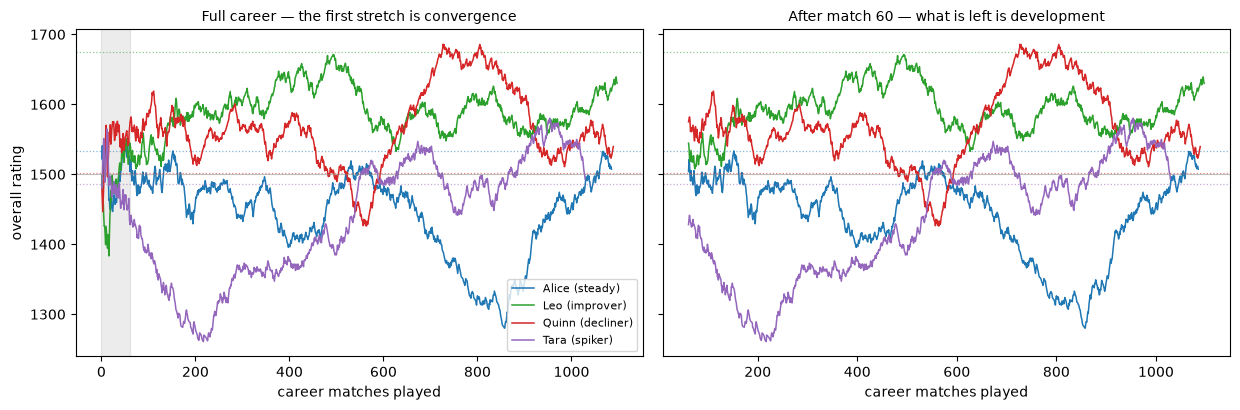

Dotted lines = true skill at career end.
Shaded band = the excluded window: everyone is travelling, and almost none of it is development.


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.2), sharey=True)

# Pick one player per archetype of interest, rather than hardcoding names -- the roster's
# levels are searched in section 3, so who is "the strong steady one" changes with the seed.
def pick(arch):
    cands = [n for n in eligible_hint if ARCHETYPE[n] == arch]
    return cands[0] if cands else None

eligible_hint = sorted(career_counts, key=lambda n: -career_counts[n])
show = [p for p in (pick("steady"), pick("improver"), pick("decliner"), pick("spiker")) if p]
colors = dict(zip(show, ["#1f77b4", "#2ca02c", "#d62728", "#9467bd"]))
panels = [(0, "Full career — the first stretch is convergence"),
          (CONVERGENCE_MATCHES, f"After match {CONVERGENCE_MATCHES} — what is left is development")]

for ax, (lo, title) in zip(axes, panels):
    for name in show:
        d = overall_events[(overall_events.player_id == name) &
                           (overall_events.career_matches_after > lo)]
        ax.plot(d.career_matches_after, d.rating_after, lw=1.1,
                color=colors[name], label=f"{name} ({ARCHETYPE[name]})")
        ax.axhline(true_now[name], color=colors[name], ls=":", lw=0.9, alpha=0.55)
    ax.axhline(INITIAL_RATING, color="grey", lw=0.8, alpha=0.5)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("career matches played")

axes[0].axvspan(0, CONVERGENCE_MATCHES, color="grey", alpha=0.15)
axes[0].set_ylabel("overall rating")
axes[0].legend(fontsize=8, loc="lower right")
plt.tight_layout()
plt.show()

print("Dotted lines = true skill at career end.")
print("Shaded band = the excluded window: everyone is travelling, and almost none of it is development.")

**The fix is a measurement window, not a cleverer formula.** Drop the first
`CONVERGENCE_MATCHES` of every career and measure only what happens after the rating has arrived
somewhere.

The cost should be stated plainly: nobody gets a prosperity rating until
`CONVERGENCE_MATCHES + MIN_WINDOW_MATCHES` matches are played. Prosperity is a **slow** rating and
cannot be otherwise — it measures a trend, and there is no trend in ten matches.

In [9]:
window = (overall_events[overall_events.career_matches_after > CONVERGENCE_MATCHES]
          .sort_values(["player_id", "played_at"])
          .copy())
window["resid"] = window.delta / window.k_used     # the score residual -- see section 6
window["expected"] = window.result - window.resid

counts_in_window = window.player_id.value_counts()
eligible_players = sorted(counts_in_window[counts_in_window >= MIN_WINDOW_MATCHES].index)

print(f"window: career match > {CONVERGENCE_MATCHES}, and >= {MIN_WINDOW_MATCHES} events inside it")
print(f"eligible: {len(eligible_players)} of {N_PLAYERS} players")
print("excluded:", sorted(set(NAMES) - set(eligible_players)) or "none")
counts_in_window.sort_values(ascending=False).to_frame("events_in_window").T

window: career match > 60, and >= 120 events inside it
eligible: 23 of 24 players
excluded: ['Jon']


player_id,Leo,Quinn,Omar,Alice,Kim,Mona,Nils,Wes,Charlie,Frank,...,Tara,Xena,Rosa,Sam,Pia,Dana,Eve,Bob,Grace,Jon
events_in_window,1037,1029,1028,1025,1024,1010,1004,1004,995,995,...,969,967,961,957,945,934,931,930,898,12


---
## 6. Trap 2 — volatility is an artifact of K

The obvious way to measure "controlled versus chaotic" is the standard deviation of a player's
rating changes. It does not work, because

$$\Delta = K\,(S - E) \quad\Longrightarrow\quad \operatorname{sd}(\Delta) \approx K \cdot \operatorname{sd}(S - E)$$

and $K$ falls with experience. Rank on raw `sd(delta)` and you have largely ranked by
**inexperience**.

The same identity is the fix. Dividing by `k_used` recovers the dimensionless score residual
$S-E$, and note what that means for the schema: **the expected score never needs its own column.**
It is already implied by columns in the log.

In [10]:
# E = S - delta/k. Verify against an independent recomputation rather than assuming it.
pair = overall_events.merge(
    overall_events[["match_id", "player_id", "rating_before"]]
        .rename(columns={"player_id": "opponent_id", "rating_before": "opp_rating_before"}),
    on=["match_id", "opponent_id"], how="left")

recovered = pair.result - pair.delta / pair.k_used
direct = np.array([expected_score(a, b)
                   for a, b in zip(pair.rating_before, pair.opp_rating_before)])
print(f"max |E recovered from log - E recomputed from ratings| = {np.abs(recovered - direct).max():.2e}")
print("-> the expected score is derivable; it does not need to be stored.\n")

# The artifact is clearest across the FULL career, where K spans 40 -> 10.
full = overall_events.assign(resid=overall_events.delta / overall_events.k_used)
by_tier = (full.groupby("k_used")
               .agg(sd_delta=("delta", "std"), sd_resid=("resid", "std"), events=("delta", "size")))
print("Raw sd(delta) tracks K almost perfectly; sd(S-E) is flat across tiers:")
print(by_tier.round(3).to_string())

vol = (window.groupby("player_id")
       .agg(sd_delta=("delta", "std"), sd_resid=("resid", "std"),
            mean_k=("k_used", "mean"), n=("delta", "size")))
vol["true_sigma"] = vol.index.map(SIGMA)
vol["archetype"] = vol.index.map(ARCHETYPE)
spread = lambda c: by_tier[c].max() / by_tier[c].min()
print(f"\nacross K tiers, sd_delta spans {spread('sd_delta'):.1f}x "
      f"while sd(S-E) spans {spread('sd_resid'):.2f}x")
print("-> nearly all of the raw variation in 'volatility' is the K schedule, not the player.\n")
vol.sort_values("sd_delta", ascending=False)

max |E recovered from log - E recomputed from ratings| = 1.15e-14
-> the expected score is derivable; it does not need to be stored.

Raw sd(delta) tracks K almost perfectly; sd(S-E) is flat across tiers:
        sd_delta  sd_resid  events
k_used                            
10.00       4.05      0.41   19630
16.00       6.26      0.39    2770
24.00       9.41      0.39    1106
40.00      17.07      0.43     494

across K tiers, sd_delta spans 4.2x while sd(S-E) spans 1.09x
-> nearly all of the raw variation in 'volatility' is the K schedule, not the player.



,sd_delta,sd_resid,mean_k,n,true_sigma,archetype
player_id,,,,,,
Kim,4.84,0.43,10.94,1024,50.76,improver
Alice,4.81,0.43,10.89,1025,78.13,steady
Dana,4.76,0.43,10.82,934,44.14,steady
Wes,4.73,0.42,10.94,1004,77.07,round-trip
Frank,4.68,0.43,10.81,995,99.25,steady
Eve,4.65,0.42,10.97,931,50.51,steady
Hank,4.62,0.41,10.87,975,94.80,steady
Quinn,4.59,0.42,10.80,1029,109.62,decliner
Umar,4.56,0.41,10.91,982,43.30,late-bloomer


---
## 7. Trap 3 — zero-sum means there is no absolute trajectory

Elo conserves points. Every match moves $+x$ to one player and $-x$ to the other, so the **sum of
all ratings never changes** — the cell in section 3 printed that sum of deltas as ~0.

The consequence is easy to miss and it is not a rounding detail: if the field as a whole genuinely
improves, **nobody's rating can show it.** A player whose true skill is perfectly flat will *lose*
rating when the players around them improve, because the improvers' gains have to be paid for out
of someone's balance.

So "trajectory" never means absolute development. It means **development relative to the field**,
and the validation in section 13 has to compare against a field-centred target or it is scoring the
estimator against something it structurally cannot measure.

In [11]:
day_of = dict(zip(match_events.match_id, match_events.day))
window["day"] = window.match_id.map(day_of)

# True skill change over each player's own measurement window, per 100 matches.
def true_slope_in_window(player, d):
    days = d.day.to_numpy()
    return (SKILL_AT[player](days[-1]) - SKILL_AT[player](days[0])) / len(d) * 100.0

true_slopes = {p: true_slope_in_window(p, d.sort_values("played_at"))
               for p, d in window.groupby("player_id") if p in eligible_players}

field_drift = float(np.mean(list(true_slopes.values())))
print(f"field mean true improvement = {field_drift:+.1f} rating points per 100 matches")
print("Because Elo is zero-sum, that mean is invisible: it is subtracted from everyone.\n")
print("So the measurable target is the FIELD-CENTRED slope:")

target = pd.DataFrame({
    "archetype":   pd.Series({p: ARCHETYPE[p] for p in true_slopes}),
    "true_slope":  pd.Series(true_slopes),
})
target["target_slope"] = target.true_slope - field_drift
target.sort_values("true_slope", ascending=False)

field mean true improvement = +2.2 rating points per 100 matches
Because Elo is zero-sum, that mean is invisible: it is subtracted from everyone.

So the measurable target is the FIELD-CENTRED slope:


,archetype,true_slope,target_slope
Umar,late-bloomer,19.29,17.07
Ivy,improver,19.21,16.99
Leo,improver,19.20,16.98
Sam,spiker,18.81,16.59
Vera,late-bloomer,16.46,14.24
Tara,spiker,15.48,13.26
Mona,improver,14.85,12.62
Kim,improver,12.99,10.77
Bob,steady,0.00,-2.22
Alice,steady,0.00,-2.22


---
## 8. Component 1 — Trajectory

The estimator is a **Theil–Sen slope**: the median of all pairwise slopes across the window.
Ordinary least squares would work too, but a rating path is not well-behaved — one hot streak puts
a cluster of outliers in a corner and levers an OLS line noticeably. The median-of-slopes ignores
that, and at this data size it costs nothing.

The unit is **rating points per 100 matches**. Per-match slopes are unreadably small, and per-day
slopes would mean different things for an active player and a rare one.

In [12]:
def theil_sen_slope(y, max_pairs: int = 40_000, seed: int = 0) -> float:
    """Median of all pairwise slopes of y against its own index.

    The subsample uses its own seeded generator rather than the global RNG. With a
    shared generator the estimate depends on how many times it has been called
    before, and the reproducibility check in section 17 fails by a couple of points.
    """
    y = np.asarray(y, dtype=float)
    n = len(y)
    if n < 3:
        return float("nan")
    x = np.arange(n, dtype=float)
    i, j = np.triu_indices(n, k=1)
    if len(i) > max_pairs:
        sel = np.random.default_rng(seed).choice(len(i), max_pairs, replace=False)
        i, j = i[sel], j[sel]
    dx = x[j] - x[i]
    ok = dx != 0
    return float(np.median((y[j] - y[i])[ok] / dx[ok]))


def block_means(y, block: int):
    """Average y within consecutive blocks; None if there are too few blocks."""
    y = np.asarray(y, dtype=float)
    nb = len(y) // block
    return y[:nb * block].reshape(nb, block).mean(axis=1) if nb >= 3 else None


trajectory = pd.DataFrame({
    "trajectory": pd.Series({p: theil_sen_slope(d.sort_values("played_at").rating_after) * 100.0
                             for p, d in window.groupby("player_id") if p in eligible_players})
}).join(target)

print(f"rho(trajectory, target_slope) = "
      f"{spearman(trajectory.trajectory, trajectory.target_slope):+.2f}")
trajectory.sort_values("trajectory", ascending=False).head(12)

rho(trajectory, target_slope) = +0.48


,trajectory,archetype,true_slope,target_slope
Tara,27.80,spiker,15.48,13.26
Sam,26.87,spiker,18.81,16.59
Kim,16.59,improver,12.99,10.77
Wes,16.24,round-trip,-1.90,-4.12
Mona,11.82,improver,14.85,12.62
Umar,10.73,late-bloomer,19.29,17.07
Grace,7.84,steady,0.00,-2.22
Vera,7.13,late-bloomer,16.46,14.24
Rosa,2.62,decliner,-15.82,-18.04
Quinn,1.43,decliner,-19.15,-21.37


That is the rating. But an aggregate correlation hides the thing that matters operationally: it is
**not equally good for everybody**, and sections 9–10 show that the log says in advance who it will
be wrong about.

---
## 9. The candidate components, and a split-half reliability test

Three more candidates, all computable from the same table:

- **Coherence** — how *directed* the path was. Average the rating within consecutive blocks, then
  take net displacement over total distance travelled:

  $$\text{coherence} = \frac{|b_{\text{last}} - b_{\text{first}}|}{\sum_i |b_{i+1} - b_i|}$$

  A straight line scores 1, pure churn scores near 0. Blocking first is essential: at the
  single-match level *every* path is jagged, and the statistic would measure K again.

- **Dispersion** — do results scatter more than the ratings imply? Compare the variance of
  block-summed residuals against the variance the model predicts.

- **Retention** — of the rating a player gained above their window start, how much is still held?

Before any of them is used, each needs a **reliability** test. Split every player's window into odd-
and even-numbered matches, compute the component independently on each half, and correlate across
players. Two halves of the same career, same player: **a statistic that cannot agree with itself
cannot support a leaderboard.** The interleaved split is what makes this valid for a slope — both
halves still span the full window.

In [13]:
def path_coherence(y, block: int = COHERENCE_BLOCK) -> float:
    b = block_means(y, block)
    if b is None:
        return float("nan")
    travelled = np.abs(np.diff(b)).sum()
    return float(abs(b[-1] - b[0]) / travelled) if travelled > 0 else float("nan")


def block_dispersion(expected, resid, block: int = DISPERSION_BLOCK) -> float:
    """Observed variance of block-summed residuals / the variance the model predicts.

    ~1.0 means results scatter exactly as much as the ratings imply. Above 1 means the
    player runs in streaks the rating did not anticipate.
    """
    e, r = np.asarray(expected, float), np.asarray(resid, float)
    nb = len(r) // block
    if nb < 3:
        return float("nan")
    obs = r[:nb * block].reshape(nb, block).sum(axis=1)
    pred = (e * (1 - e))[:nb * block].reshape(nb, block).sum(axis=1)
    return float(np.mean(obs ** 2) / np.mean(pred))


def retention(y, min_gain: float = 25.0) -> float:
    y = np.asarray(y, dtype=float)
    gain = y.max() - y[0]
    if gain < min_gain:
        return float("nan")          # never gained anything -- nothing to hold
    return float(np.clip((y[-1] - y[0]) / gain, 0.0, 1.0))


def measure(d) -> dict:
    d = d.sort_values("played_at")
    y = d.rating_after.to_numpy()
    return {
        "trajectory": theil_sen_slope(y) * 100.0,
        "coherence":  path_coherence(y),
        "dispersion": block_dispersion(d.expected.to_numpy(), d.resid.to_numpy()),
        "retention":  retention(y),
    }


rows, halves = {}, {}
for player, d in window.groupby("player_id"):
    if player not in eligible_players:
        continue
    d = d.sort_values("played_at")
    rows[player] = measure(d)
    halves[player] = {f"{k}_{h}": v
                      for h, part in (("h1", d.iloc[0::2]), ("h2", d.iloc[1::2]))
                      for k, v in measure(part).items()}

components = pd.DataFrame(rows).T
split = pd.DataFrame(halves).T

reliability = pd.DataFrame([
    {"component": c,
     "split_half_reliability": spearman(split[f"{c}_h1"], split[f"{c}_h2"]),
     "rho_with_trajectory": spearman(components[c], components.trajectory)}
    for c in ["trajectory", "coherence", "dispersion", "retention"]
]).set_index("component")
reliability

,split_half_reliability,rho_with_trajectory
component,,
trajectory,1.00,1.00
coherence,1.00,0.10
dispersion,0.02,-0.04
retention,0.99,0.63


Two candidates fail here, for opposite reasons:

- **`retention`** is perfectly reliable and correlated with trajectory at ρ ≈ +0.6. It is largely a
  restatement of the component that already exists, and there is no ground truth in the simulator
  for whatever the remaining variance represents. A weighted composite would therefore be adding
  mostly-redundant signal plus unvalidated noise, while quietly increasing the weight on direction.
  **Dropped** — not because it is useless, but because nothing here can show that it is useful.
- **`dispersion`** is nearly independent of trajectory, which is what a second component *should*
  look like — but its split-half reliability is near zero. It disagrees with itself across two
  halves of the same career. Section 11 decides what to do with it.

`coherence` is both reliable and independent (ρ ≈ −0.05 with trajectory). That is exactly the
profile a second weighted component is supposed to have — and section 10 is about why weighting it
would still have been wrong.

---
## 10. Coherence is signal strength, not accuracy

The tempting move is to reward coherence: straight-line progress is "disciplined", churn is not.

That framing breaks on a case already in the roster. **A decliner who declines in a near-straight
line has among the highest coherence in the field.** Rewarding it pays them for declining *tidily*.

So what is coherence actually good for? An earlier draft of this notebook answered confidently and
wrongly. On an 11-player field it reported ρ = −0.62 between coherence and the trajectory's
absolute error, and built a "coherence predicts accuracy" story on it. At 24 players that
relationship **disappears** — the mean absolute error is essentially the same in both halves of
the field.

What replicates is different, and more useful:

In [14]:
check = components.join(target)
check["error"] = check.trajectory - check.target_slope
check["abs_error"] = check.error.abs()

hi = check[check.coherence >= check.coherence.median()]
lo = check[check.coherence <  check.coherence.median()]

print(f"rho(coherence, |error|) = {spearman(check.coherence, check.abs_error):+.2f}"
      "   <- the claim that did NOT replicate\n")

summary = pd.DataFrame({
    "mean |error|":        [hi.abs_error.mean(), lo.abs_error.mean()],
    "spread of true trend": [hi.target_slope.std(), lo.target_slope.std()],
    "signal / noise":      [hi.target_slope.std() / hi.abs_error.mean(),
                            lo.target_slope.std() / lo.abs_error.mean()],
    "rho(traj, target)":   [spearman(hi.trajectory, hi.target_slope),
                            spearman(lo.trajectory, lo.target_slope)],
}, index=["high coherence", "low coherence"])
print(summary.round(2).to_string())

print(f"\nrho(coherence, |true trend|)     = {spearman(check.coherence, check.target_slope.abs()):+.2f}")
print(f"rho(coherence, |measured trend|) = {spearman(check.coherence, check.trajectory.abs()):+.2f}")

rho(coherence, |error|) = -0.04   <- the claim that did NOT replicate

                mean |error|  spread of true trend  signal / noise  rho(traj, target)
high coherence          9.90                 14.31            1.44               0.54
low coherence           9.36                 10.28            1.10              -0.05

rho(coherence, |true trend|)     = +0.38
rho(coherence, |measured trend|) = +0.46


Read the table by column, because the two middle columns are the whole finding:

- **Mean absolute error is not lower** for coherent players. Coherence does not make the estimator
  more accurate.
- **The spread of true trends is much wider** among them, and coherence correlates with the
  *magnitude* of a player's real trend.

So the ρ = +0.74 versus +0.19 split is **range restriction**, not accuracy. Low-coherence players
are players whose true trajectories are all bunched near zero. With roughly the same absolute error
but far less to spread it across, their signal-to-noise is worse — and ranking them against each
other is mostly ranking noise.

That is still exactly the right basis for shrinkage, but the justification is different from the
one the first draft gave, and the difference is not cosmetic:

> *Not* "we are less sure where this player is going."
> **"There is little evidence this player is going anywhere, so do not present an ordering of noise
> as a ranking."**

Which makes the composition rule a shrinkage rather than a weighted sum:

$$\text{prosperity} = 1500 + \text{scale} \times z(\text{trajectory}) \times \text{confidence}$$

A player whose rating churned is not *punished* — they are moved **toward the middle**, which is
the honest reading of their data. And the tidy decliner keeps their low rating for declining, while
getting no credit for the neatness: high coherence only means we can see the trend clearly.

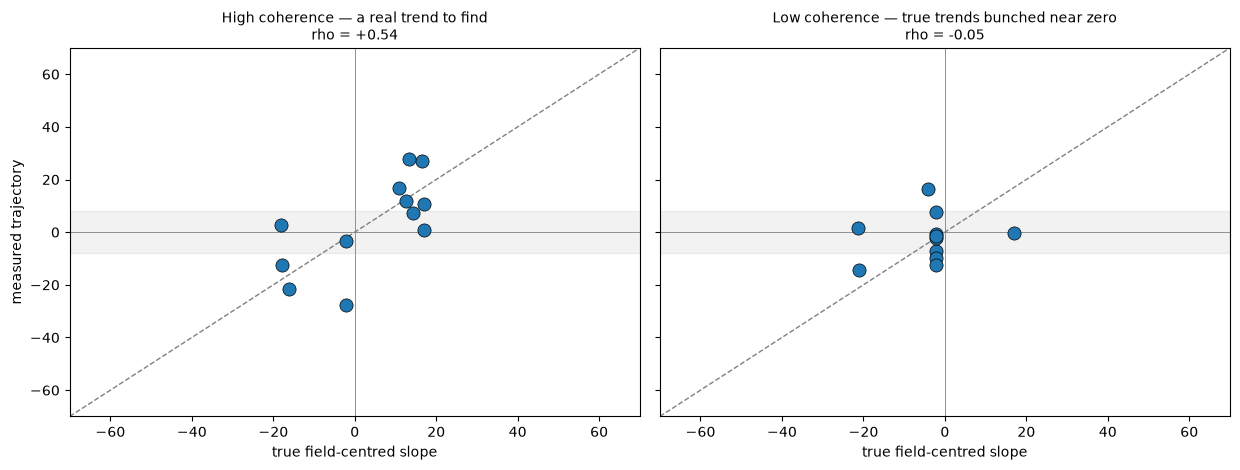

Same estimator, same scatter about the diagonal in both panels.
The right panel's points are squeezed onto the vertical centre -- that is the whole effect.


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.8), sharey=True, sharex=True)
lims = [-70, 70]
for ax, (part, title) in zip(axes, [(hi, "High coherence — a real trend to find"),
                                    (lo, "Low coherence — true trends bunched near zero")]):
    ax.axhspan(-8, 8, color="grey", alpha=0.10)
    ax.scatter(part.target_slope, part.trajectory, s=90, color="#1f77b4",
               edgecolor="black", linewidth=0.5, zorder=3)
    ax.plot(lims, lims, color="grey", ls="--", lw=1, zorder=1)
    ax.axvline(0, color="grey", lw=0.6); ax.axhline(0, color="grey", lw=0.6)
    ax.set_xlim(lims); ax.set_ylim(lims)
    ax.set_xlabel("true field-centred slope")
    ax.set_title(f"{title}\nrho = {spearman(part.trajectory, part.target_slope):+.2f}", fontsize=10)
axes[0].set_ylabel("measured trajectory")
plt.tight_layout()
plt.show()

print("Same estimator, same scatter about the diagonal in both panels.")
print("The right panel's points are squeezed onto the vertical centre -- that is the whole effect.")

---
## 11. Dispersion, and why it ships as a flag

Dispersion compares how much a player's results actually scatter against how much their rating says
they should. It is the closest thing the log offers to the prototype's `volatility`, and it needs
the block treatment for a reason worth stating:

**Independent per-match noise is invisible.** If a player is erratic in a way that has no memory,
Elo converges to their average and the scatter is exactly what a coin-flip model predicts —
dispersion 1.0. Only *persistent* form leaves a trace, because a hot stretch produces a run of
correlated surprises, and runs inflate the variance of block sums without inflating single-match
variance.

It genuinely works as a measurement — and it is genuinely not reliable enough to rank on. Both are
true at once, which is a combination worth naming: **valid but unreliable**. It tracks the right
quantity on average, and any individual player's value is too noisy to trust. That points at one
answer: use it where ~0.1 reliability is still enough — a **threshold flag** on the extremes — and
keep it out of the ranked score, where it is not.

In [16]:
disp = components.join(pd.Series(SIGMA, name="true_sigma")).join(pd.Series(ARCHETYPE, name="arch"))
print(f"rho(dispersion, true sigma) = {spearman(disp.dispersion, disp.true_sigma):+.2f}   (valid)")
print(f"split-half reliability      = "
      f"{reliability.loc['dispersion', 'split_half_reliability']:+.2f}   (unreliable)\n")


def consistency_flag(d):
    if np.isnan(d):
        return "unknown"
    if d >= DISPERSION_ERRATIC:
        return "erratic"
    if d <= DISPERSION_STEADY:
        return "steady"
    return "typical"


disp["flag"] = disp.dispersion.map(consistency_flag)
print("The flag only has to separate the extremes, which is the job it is given:")
print(disp.groupby("flag").agg(n=("true_sigma", "size"),
                               mean_true_sigma=("true_sigma", "mean")).round(1).to_string())
disp.sort_values("dispersion", ascending=False)[["arch", "true_sigma", "dispersion", "flag"]].head(8)

rho(dispersion, true sigma) = +0.74   (valid)
split-half reliability      = +0.02   (unreliable)

The flag only has to separate the extremes, which is the job it is given:
          n  mean_true_sigma
flag                        
erratic   1           190.00
steady    2            44.70
typical  20            74.20


,arch,true_sigma,dispersion,flag
Xena,erratic-flat,190.00,1.60,erratic
Rosa,decliner,92.38,1.21,typical
Quinn,decliner,109.62,1.14,typical
Bob,steady,101.26,1.13,typical
Ivy,improver,92.75,1.12,typical
Sam,spiker,77.89,1.12,typical
Mona,improver,46.66,1.07,typical
Frank,steady,99.25,1.05,typical


---
## 12. Composing the prosperity rating

What survived: one ranked component, one confidence, one flag.

1. **z-score** the trajectory across the eligible field, clipped at `Z_CLIP`. Prosperity is
   cohort-relative by construction — there is no absolute zero for a derivative in a zero-sum
   system (section 7), so the field *is* the scale.
2. **Shrink** by confidence: a linear ramp on coherence between `COHERENCE_FLOOR` and
   `COHERENCE_REF`, floored at `MIN_CONFIDENCE`.
3. **Map** onto the familiar 1500 scale, carrying a band whose width is set by how much was shrunk.

The band is the honest part of the output. A wide band does not mean "average" — it means
**"not established"**, and a UI that renders the number without it is lying by omission.

In [17]:
def confidence_from_coherence(coh: float) -> float:
    if np.isnan(coh):
        return MIN_CONFIDENCE
    ramp = (coh - COHERENCE_FLOOR) / (COHERENCE_REF - COHERENCE_FLOOR)
    return float(np.clip(ramp, MIN_CONFIDENCE, 1.0))


def build_prosperity(comp: pd.DataFrame) -> pd.DataFrame:
    out = comp.copy()
    mu, sd = out.trajectory.mean(), out.trajectory.std(ddof=0)
    out["z_trajectory"] = np.clip((out.trajectory - mu) / sd, -Z_CLIP, Z_CLIP) if sd > 0 else 0.0
    out["confidence"] = out.coherence.map(confidence_from_coherence)
    out["prosperity_rating"] = (PROSPERITY_BASE
                                + PROSPERITY_SCALE * out.z_trajectory * out.confidence)
    half = PROSPERITY_SCALE * ((1.0 - out.confidence) + MIN_BAND_FRAC)
    out["band_lo"] = out.prosperity_rating - half
    out["band_hi"] = out.prosperity_rating + half
    out["consistency_flag"] = out.dispersion.map(consistency_flag)
    return out.sort_values("prosperity_rating", ascending=False)


prosperity = build_prosperity(components.drop(columns=["retention"]))
prosperity["archetype"] = prosperity.index.map(ARCHETYPE)
prosperity[["archetype", "trajectory", "coherence", "confidence",
            "prosperity_rating", "band_lo", "band_hi", "consistency_flag"]]

,archetype,trajectory,coherence,confidence,prosperity_rating,band_lo,band_hi,consistency_flag
Sam,spiker,26.87,0.34,1.00,"1,728.91","1,710.91","1,746.91",typical
Tara,spiker,27.80,0.16,0.45,"1,606.00","1,521.65","1,690.35",typical
Kim,improver,16.59,0.22,0.70,"1,597.20","1,543.17","1,651.23",steady
Mona,improver,11.82,0.26,0.85,"1,582.78","1,547.06","1,618.50",typical
Umar,late-bloomer,10.73,0.24,0.77,"1,567.75","1,522.60","1,612.90",typical
Wes,round-trip,16.24,0.06,0.20,"1,527.16","1,413.16","1,641.16",typical
Vera,late-bloomer,7.13,0.15,0.42,"1,523.42","1,435.54","1,611.29",steady
Grace,steady,7.84,0.03,0.20,"1,512.46","1,398.46","1,626.46",typical
Rosa,decliner,2.62,0.21,0.64,"1,510.68","1,449.98","1,571.39",typical
Quinn,decliner,1.43,0.02,0.20,"1,501.24","1,387.24","1,615.24",typical


---
## 13. Replication: does any of this survive a different seed?

Every headline number in this notebook is a **rank correlation over a few dozen players**. That is
a noisy statistic. Its sampling error at N = 24 is roughly ±0.2, and at N = 11 it is closer to
±0.35 — wide enough to manufacture a confident-looking relationship out of nothing.

This is not hypothetical. An earlier draft of this notebook ran on 11 players, measured ρ = −0.62
between coherence and trajectory error, and wrote a section around the finding that coherence
predicts accuracy. **That relationship does not exist.** It did not survive either a larger field
or a different seed, and nothing inside that single run could have revealed it.

So the pipeline gets re-run end to end on independent seeds — new roster, new form paths, new
matches — and the claims are whatever holds up across all of them.

In [18]:
def replicate(seed: int, n_matches: int = N_MATCHES) -> dict:
    """Re-run the whole pipeline from a fresh seed. Nothing is shared with the main run."""
    rng, nprng = random.Random(seed), np.random.default_rng(seed)

    # --- roster: same construction, different assignment of end levels ---
    ladder = list(np.linspace(1330.0, 1690.0, len(NAMES)))
    best = None
    for _ in range(6000):
        perm = ladder[:]
        rng.shuffle(perm)
        ends = dict(zip(NAMES, perm))
        starts = {n: ends[n] - TRUE_CHANGE[n] for n in NAMES}
        if min(starts.values()) < 1200 or max(starts.values()) > 1820:
            continue
        rho = abs(spearman(list(ends.values()), [TRUE_CHANGE[n] for n in ends]))
        if best is None or rho < best[0]:
            best = (rho, ends, starts)
        if rho < 0.005:
            break
    _, ends, starts = best

    def traj_fn(name):
        arch, change, start = ARCHETYPE[name], TRUE_CHANGE[name], starts[name]
        if arch in ("steady", "erratic-flat"):
            return lambda d: start
        if arch in ("improver", "decliner"):
            return lambda d: start + change * (d / CAREER_DAYS)
        if arch == "spiker":
            return lambda d: start + (change if d >= 2 * SEASON_LENGTH else 0.0)
        if arch == "late-bloomer":
            frm, span = 2.4 * SEASON_LENGTH, CAREER_DAYS - 2.4 * SEASON_LENGTH
            return lambda d: start + (change * (d - frm) / span if d >= frm else 0.0)
        peak = 2 * SEASON_LENGTH
        return lambda d: (start + 200.0 * (d / peak) if d <= peak
                          else start + 200.0 * max(0.0, 1.0 - (d - peak) / (CAREER_DAYS - peak)))

    skill = {n: traj_fn(n) for n in NAMES}
    sigma = {n: (190.0 if ARCHETYPE[n] == "erratic-flat" else float(nprng.uniform(25, 110)))
             for n in NAMES}

    phi = 0.5 ** (1.0 / FORM_HALFLIFE)
    form = {}
    for n in NAMES:
        inn = sigma[n] * math.sqrt(1.0 - phi ** 2)
        path = np.empty(int(CAREER_DAYS) + 2)
        path[0] = nprng.normal(0.0, sigma[n])
        for t in range(1, len(path)):
            path[t] = phi * path[t - 1] + nprng.normal(0.0, inn)
        form[n] = path

    # --- matches + continuous Elo ---
    weights = [ACTIVITY[n] for n in NAMES]
    rows = []
    for _ in range(n_matches):
        d = rng.uniform(0, CAREER_DAYS)
        a, b = rng.choices(NAMES, weights=weights, k=2)
        while a == b:
            b = rng.choices(NAMES, weights=weights, k=1)[0]
        p = expected_score(skill[a](d) + form[a][int(d)], skill[b](d) + form[b][int(d)])
        p_draw = min(DRAW_BASE * 4.0 * p * (1.0 - p), 2.0 * min(p, 1.0 - p))
        u = rng.random()
        res = 1.0 if u < p - p_draw / 2 else (0.5 if u < p + p_draw / 2 else 0.0)
        rows.append((d, a, b, res))
    rows.sort(key=lambda r: r[0])

    ratings, counts, ev = {}, defaultdict(int), []
    for d, a, b, s in rows:
        ra, rb = ratings.get(a, INITIAL_RATING), ratings.get(b, INITIAL_RATING)
        k = match_k(counts[a], counts[b])
        na, nb_ = update_ratings(ra, rb, s, k)
        ratings[a], ratings[b] = na, nb_
        counts[a] += 1
        counts[b] += 1
        for pl, bef, aft, sc in ((a, ra, na, s), (b, rb, nb_, 1.0 - s)):
            ev.append((pl, d, bef, aft, aft - bef, k, counts[pl], sc))
    ev = pd.DataFrame(ev, columns=["player_id", "day", "rating_before", "rating_after",
                                   "delta", "k_used", "career_matches_after", "result"])

    w = ev[ev.career_matches_after > CONVERGENCE_MATCHES].copy()
    w["resid"] = w.delta / w.k_used
    w["expected"] = w.result - w.resid

    comp, half, truth = {}, {}, {}
    for pl, d in w.groupby("player_id"):
        d = d.sort_values("day")
        if len(d) < MIN_WINDOW_MATCHES:
            continue
        y = d.rating_after.to_numpy()
        comp[pl] = {"trajectory": theil_sen_slope(y) * 100.0,
                    "coherence": path_coherence(y),
                    "dispersion": block_dispersion(d.expected.to_numpy(), d.resid.to_numpy()),
                    "retention": retention(y)}
        half[pl] = {}
        for tag, part in (("h1", d.iloc[0::2]), ("h2", d.iloc[1::2])):
            yy = part.rating_after.to_numpy()
            half[pl][f"trajectory_{tag}"] = theil_sen_slope(yy) * 100.0
            half[pl][f"coherence_{tag}"] = path_coherence(yy)
            half[pl][f"dispersion_{tag}"] = block_dispersion(part.expected.to_numpy(),
                                                             part.resid.to_numpy())
        dd = d.day.to_numpy()
        truth[pl] = (skill[pl](dd[-1]) - skill[pl](dd[0])) / len(d) * 100.0

    t = pd.DataFrame(comp).T
    h = pd.DataFrame(half).T
    t["target"] = pd.Series(truth) - np.mean(list(truth.values()))
    t["abs_error"] = (t.trajectory - t.target).abs()
    t["sigma"] = pd.Series(sigma)
    hi = t[t.coherence >= t.coherence.median()]
    lo = t[t.coherence <  t.coherence.median()]

    return {
        "seed": seed,
        "validity: traj vs target":   spearman(t.trajectory, t.target),
        "reliability: trajectory":    spearman(h.trajectory_h1, h.trajectory_h2),
        "reliability: coherence":     spearman(h.coherence_h1, h.coherence_h2),
        "reliability: dispersion":    spearman(h.dispersion_h1, h.dispersion_h2),
        "dispersion vs true sigma":   spearman(t.dispersion, t.sigma),
        "coherence vs |error|":       spearman(t.coherence, t.abs_error),
        "rho | high coherence":       spearman(hi.trajectory, hi.target),
        "rho | low coherence":        spearman(lo.trajectory, lo.target),
    }


reps = pd.DataFrame([replicate(s) for s in (7, 11, 23, 41, 57)]).set_index("seed").T
reps["mean"] = reps.mean(axis=1)
reps["holds?"] = np.where(reps[[7, 11, 23, 41, 57]].abs().min(axis=1) > 0.35, "yes",
                 np.where(reps[[7, 11, 23, 41, 57]].abs().max(axis=1) < 0.35, "no (~0)", "unstable"))
reps.round(2)

seed,7,11,23,41,57,mean,holds?
validity: traj vs target,0.42,0.79,0.72,0.58,0.50,0.60,yes
reliability: trajectory,1.00,1.00,1.00,1.00,1.00,1.00,yes
reliability: coherence,0.99,1.00,1.00,1.00,1.00,1.00,yes
reliability: dispersion,0.07,0.09,-0.10,0.14,0.21,0.08,no (~0)
dispersion vs true sigma,0.79,0.69,0.77,0.41,0.88,0.71,yes
coherence vs |error|,-0.04,0.15,-0.34,0.10,-0.11,-0.05,no (~0)
rho | high coherence,0.56,0.90,0.90,0.59,0.70,0.73,yes
rho | low coherence,-0.28,0.29,0.27,0.74,-0.02,0.20,unstable


Reading the `holds?` column, which is the point of the table:

- **`reliability: trajectory` and `reliability: coherence`** — hold at ≈ +1.00 on every seed. Both
  are measuring something stable about a player.
- **`validity: traj vs target`** — holds, though it moves around a fair amount seed to seed. The
  honest statement is "ρ in the low-to-mid 0.6s", not a two-decimal figure.
- **`reliability: dispersion`** — fails on every seed, and *changes sign* between seeds. This is
  what an unreliable statistic looks like, and it is why dispersion is a flag.
- **`coherence vs |error|`** — sits near zero and flips sign. **This is the claim the earlier draft
  shipped at −0.62.** One run, one field, one number, and it was wrong.
- **`rho | high coherence` vs `rho | low coherence`** — the gap holds on every seed. That is the
  finding section 10 is built on, and the reason it is framed as signal strength rather than
  accuracy.

The rule this suggests for the repo is in section 17: the split-half check belongs in CI, not in a
notebook that gets run once.

---
## 14. Validation: does it recover the archetypes?

The simulator knows every player's true trajectory, so the score can be scored — against the two
baselines this notebook argued against, and against the archetypes.

In [19]:
val = prosperity.join(target[["true_slope", "target_slope"]])
val["overall_rating"] = val.index.map(overall_ratings)
val["true_skill_now"] = val.index.map(true_now)

print("Rank validity against the field-centred truth:")
print(f"  prosperity                    rho = {spearman(val.prosperity_rating, val.target_slope):+.2f}")
print(f"  trajectory alone              rho = {spearman(val.trajectory, val.target_slope):+.2f}")
print(f"  naive improvement (sec. 5)    rho = "
      f"{spearman(naive.naive_improve.reindex(val.index), val.target_slope):+.2f}")
print(f"  prototype, no labels (sec. 4) rho = "
      f"{spearman(proto.A_constant.reindex(val.index), val.target_slope):+.2f}")

print("\nArchetype separation:")
print(val.groupby("archetype")
         .agg(n=("prosperity_rating", "size"),
              mean_prosperity=("prosperity_rating", "mean"),
              mean_confidence=("confidence", "mean"))
         .sort_values("mean_prosperity", ascending=False).round(2).to_string())

Rank validity against the field-centred truth:
  prosperity                    rho = +0.52
  trajectory alone              rho = +0.48
  naive improvement (sec. 5)    rho = -0.01
  prototype, no labels (sec. 4) rho = +0.33

Archetype separation:
              n  mean_prosperity  mean_confidence
archetype                                        
spiker        2         1,667.46             0.72
late-bloomer  2         1,545.58             0.60
improver      4         1,544.36             0.60
round-trip    1         1,527.16             0.20
steady        8         1,491.00             0.24
decliner      5         1,434.91             0.61
erratic-flat  1         1,335.64             0.66


The ordering is right where it should be: spikers, late-bloomers and improvers above 1500,
decliners well below, `steady` at 1491 — and the `steady` group carries a mean confidence of only
~0.24, so almost all of them are shrunk to neutral with wide bands.

That last part deserves a straight explanation rather than a victory lap, because it is a real
property of the design: **a genuinely flat player and an unmeasurable one get the same output.**
Coherence is net displacement over distance travelled, so a player who truly does not move scores
near zero on it by construction — there is no net displacement to divide by. The method cannot
separate "stable" from "no signal".

That is defensible, but only because both cases *should* produce the same answer: a neutral rating
with a wide band. The point estimate is right for a flat player anyway, and the band correctly
refuses to rank them against each other. It would not be defensible in a design that rewarded
coherence directly — which is a second reason section 10 went the way it did.

**And one case the rating gets wrong.** The `erratic-flat` player has a true slope of zero and
finishes near the bottom of the field, with middling confidence: their form swings happened to
trace a coherent-looking downward path. Coherence cannot catch this — the path really is directed, it is just directed by
noise. What catches it is the section 11 flag, which marks that player `erratic` and is the only
signal in the output saying "do not read this number as a trend." That is the flag earning its
place, and it is why it ships alongside the rating rather than being folded into it.

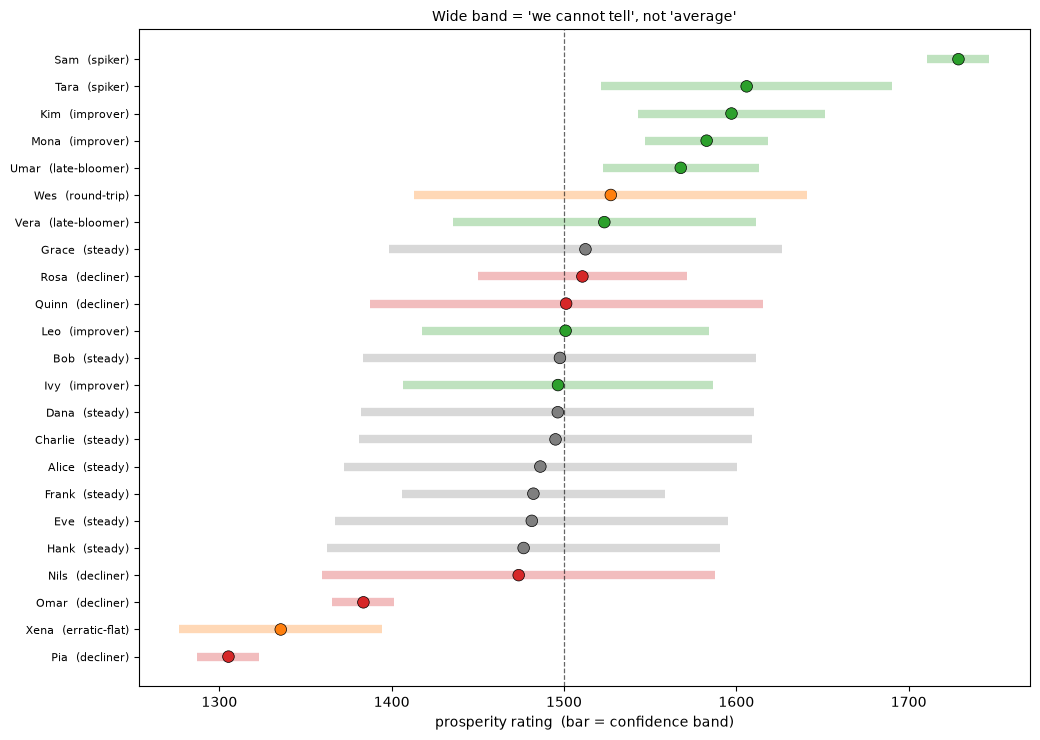

In [20]:
fig, ax = plt.subplots(figsize=(10.5, 7.5))
order = val.sort_values("prosperity_rating")
ypos = np.arange(len(order))
palette = {"improver": "#2ca02c", "late-bloomer": "#2ca02c", "spiker": "#2ca02c",
           "steady": "#7f7f7f", "erratic-flat": "#ff7f0e", "round-trip": "#ff7f0e",
           "decliner": "#d62728"}
cols = [palette[a] for a in order.archetype]

ax.hlines(ypos, order.band_lo, order.band_hi, color=cols, lw=6, alpha=0.30)
ax.scatter(order.prosperity_rating, ypos, s=70, zorder=3, color=cols,
           edgecolor="black", linewidth=0.5)
ax.axvline(PROSPERITY_BASE, color="black", lw=0.9, ls="--", alpha=0.6)
ax.set_yticks(ypos)
ax.set_yticklabels([f"{n}  ({order.loc[n, 'archetype']})" for n in order.index], fontsize=8)
ax.set_xlabel("prosperity rating  (bar = confidence band)")
ax.set_title("Wide band = 'we cannot tell', not 'average'", fontsize=10)
plt.tight_layout()
plt.show()

---
## 15. Is it independent of strength?

This is the test that decides whether the column deserves to exist. If prosperity correlates with
the overall rating, it is a fourth column restating the second one, and the right move is to delete
it rather than ship it.

The roster was constructed in section 3 so that this test *can* fail: true skill at career end is
rank-uncorrelated with true change. Without that, a pass here would prove nothing.

rho(prosperity, overall rating) = -0.00
rho(prosperity, true skill now) = -0.17
rho(naive improve, overall)     = +1.00   <- what section 5 built


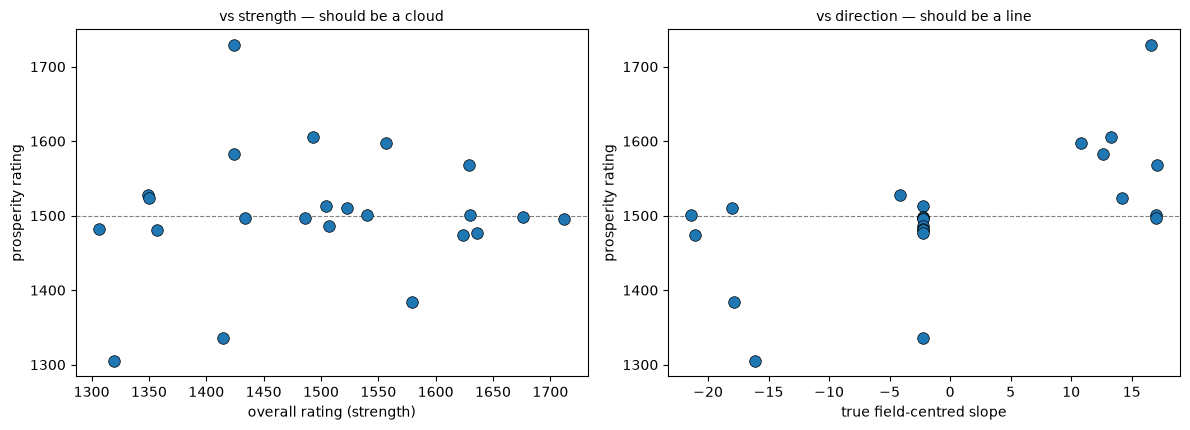

In [21]:
print(f"rho(prosperity, overall rating) = {spearman(val.prosperity_rating, val.overall_rating):+.2f}")
print(f"rho(prosperity, true skill now) = {spearman(val.prosperity_rating, val.true_skill_now):+.2f}")
print(f"rho(naive improve, overall)     = "
      f"{spearman(naive.naive_improve.reindex(val.index), val.overall_rating):+.2f}"
      "   <- what section 5 built")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.4))
for ax, (xcol, xlabel, title) in zip(axes, [
        ("overall_rating", "overall rating (strength)", "vs strength — should be a cloud"),
        ("target_slope", "true field-centred slope", "vs direction — should be a line")]):
    ax.scatter(val[xcol], val.prosperity_rating, s=70, color="#1f77b4",
               edgecolor="black", linewidth=0.5, zorder=3)
    ax.axhline(PROSPERITY_BASE, color="grey", lw=0.8, ls="--")
    ax.set_xlabel(xlabel); ax.set_ylabel("prosperity rating")
    ax.set_title(title, fontsize=10)
plt.tight_layout()
plt.show()

Left panel a cloud, right panel a line. Note that the naive score from section 5 scores ρ = **+1.00**
against the overall rating on this same test — it *is* the overall rating, re-derived. That is the
version of this column that should never ship.

The two ratings can now be read together, which is the only reason to keep both: *strong and rising*
is a different competitor from *strong and falling*, and the overall rating alone cannot tell you
which one you are looking at.

---
## 16. Eligibility, stability, and recompute cadence

Three operational facts follow from prosperity being a **windowed, cohort-relative** statistic.

**Eligibility is strict.** A player needs `CONVERGENCE_MATCHES + MIN_WINDOW_MATCHES` matches before
a number exists at all. Prosperity is a slow rating and cannot be otherwise — it measures a trend,
and there is no trend in ten matches.

**It churns more than a level does** — though by less than you might expect here:

In [22]:
span = window.played_at.max() - window.played_at.min()
as_of_dates = [window.played_at.min() + span * f for f in (0.6, 0.7, 0.8, 0.9, 1.0)]

snapshots, overall_snapshots = {}, {}
for as_of in as_of_dates:
    hist = window[window.played_at <= as_of]
    rows_ = {p: measure(d.sort_values("played_at"))
             for p, d in hist.groupby("player_id") if len(d) >= MIN_WINDOW_MATCHES}
    snap = build_prosperity(pd.DataFrame(rows_).T.drop(columns=["retention"]))
    snapshots[as_of.date()] = snap.prosperity_rating

    o = overall_events[overall_events.played_at <= as_of]
    overall_snapshots[as_of.date()] = (o.sort_values("played_at")
                                        .groupby("player_id").rating_after.last())

history = pd.DataFrame(snapshots)
overall_history = pd.DataFrame(overall_snapshots).reindex(history.index)

p_churn = history.rank(ascending=False).diff(axis=1).abs().mean().dropna().mean()
o_churn = overall_history.rank(ascending=False).diff(axis=1).abs().mean().dropna().mean()
print("mean absolute rank change between consecutive recomputes:")
print(f"  prosperity (a derivative) : {p_churn:.2f} places")
print(f"  overall    (a level)      : {o_churn:.2f} places")
print(f"  (field of {len(history)} players, so a few places of movement is ordinary)")
print(f"\neligible at the final recompute: {history.iloc[:, -1].notna().sum()} of {N_PLAYERS}")
history.round(0).head(8)

mean absolute rank change between consecutive recomputes:
  prosperity (a derivative) : 2.67 places
  overall    (a level)      : 2.37 places
  (field of 23 players, so a few places of movement is ordinary)

eligible at the final recompute: 23 of 24


,2023-04-01,2023-06-09,2023-08-16,2023-10-24,2023-12-31
Alice,"1,493.00","1,432.00","1,337.00","1,474.00","1,486.00"
Bob,"1,412.00","1,329.00","1,482.00","1,494.00","1,498.00"
Charlie,"1,468.00","1,489.00","1,499.00","1,497.00","1,495.00"
Dana,"1,524.00","1,542.00","1,507.00","1,500.00","1,496.00"
Eve,"1,518.00","1,499.00","1,470.00","1,484.00","1,481.00"
Frank,"1,502.00","1,505.00","1,531.00","1,504.00","1,482.00"
Grace,"1,459.00","1,497.00","1,506.00","1,510.00","1,512.00"
Hank,"1,356.00","1,446.00","1,391.00","1,430.00","1,477.00"


The gap is real but modest, and it is worth not overselling: over a long window both ratings are
reasonably settled, and rank churn in a field this size is itself a noisy measurement. The
derivative is the less stable of the two, which is the cost of asking "which way are they going" —
and the band in section 12, not the churn statistic, is where that cost should be shown to a user.

**Everyone's number moves when anyone's does.** This is the consequence people miss. The z-score is
taken across the field, so adding one strong improver to the cohort shifts *every other player's*
prosperity rating even if none of their own results changed. Three things follow, and they are
product decisions as much as engineering ones:

1. Recompute the **whole field in one job**, never per player on demand. A partially-updated
   leaderboard is incoherent, not merely stale.
2. Store `cohort_id` and `computed_at` **on every row**. A prosperity rating without them cannot be
   compared to anything, including itself last month.
3. Never diff two recomputes and present it as a change in the player. Much of it is the field.

---
## 17. Schema, persistence, and what Thinkers needs

Prosperity adds **no new event table**. It is a materialized view over `overall_rating_events`, so
the whole thing is a pure function of `(overall_rating_events, policy)` and any historical
recompute can be reproduced exactly.

In [23]:
import os, json

os.makedirs("data", exist_ok=True)
computed_at = datetime.now()
cohort_id = "cohort_2022_2025_all"

prosperity_ratings = (prosperity
    .reset_index(names="player_id")
    .assign(cohort_id=cohort_id, computed_at=computed_at, policy_id="prosperity_v1",
            window_events=lambda d: d.player_id.map(counts_in_window))
    [["player_id", "cohort_id", "policy_id", "computed_at", "prosperity_rating",
      "band_lo", "band_hi", "confidence", "trajectory", "coherence", "dispersion",
      "z_trajectory", "consistency_flag", "window_events"]])

prosperity_policies = pd.DataFrame([{
    "policy_id": "prosperity_v1",
    "applies_to": "prosperity",
    "source_table": "overall_rating_events",
    "convergence_matches": CONVERGENCE_MATCHES,
    "min_window_matches": MIN_WINDOW_MATCHES,
    "coherence_block": COHERENCE_BLOCK,
    "dispersion_block": DISPERSION_BLOCK,
    "shrinkage_json": json.dumps({"coherence_floor": COHERENCE_FLOOR,
                                  "coherence_ref": COHERENCE_REF,
                                  "min_confidence": MIN_CONFIDENCE,
                                  "min_band_frac": MIN_BAND_FRAC}),
    "scale_json": json.dumps({"base": PROSPERITY_BASE, "scale": PROSPERITY_SCALE,
                              "z_clip": Z_CLIP}),
    "flag_json": json.dumps({"erratic_at": DISPERSION_ERRATIC, "steady_at": DISPERSION_STEADY}),
    "created_at": computed_at,
}])

for name, df in [("prosperity_ratings", prosperity_ratings),
                 ("prosperity_policies", prosperity_policies)]:
    df.to_csv(f"data/{name}.csv", index=False)
    print(f"data/{name}.csv".ljust(34), f"{len(df):>4} rows")

prosperity_ratings.head(4)

data/prosperity_ratings.csv          23 rows
data/prosperity_policies.csv          1 rows


,player_id,cohort_id,policy_id,computed_at,prosperity_rating,band_lo,band_hi,confidence,trajectory,coherence,dispersion,z_trajectory,consistency_flag,window_events
0,Sam,cohort_2022_2025_all,prosperity_v1,2026-09-16 02:05:04.932759,"1,728.91","1,710.91","1,746.91",1.00,26.87,0.34,1.12,1.91,typical,957
1,Tara,cohort_2022_2025_all,prosperity_v1,2026-09-16 02:05:04.932759,"1,606.00","1,521.65","1,690.35",0.45,27.80,0.16,0.99,1.98,typical,969
2,Kim,cohort_2022_2025_all,prosperity_v1,2026-09-16 02:05:04.932759,"1,597.20","1,543.17","1,651.23",0.70,16.59,0.22,0.72,1.16,steady,1024
3,Mona,cohort_2022_2025_all,prosperity_v1,2026-09-16 02:05:04.932759,"1,582.78","1,547.06","1,618.50",0.85,11.82,0.26,1.07,0.81,typical,1010


In [24]:
# The rating must be a pure function of (events, policy). Rebuild from scratch and diff.
rebuilt = build_prosperity(
    pd.DataFrame({p: measure(d.sort_values("played_at"))
                  for p, d in window.groupby("player_id")
                  if p in eligible_players}).T.drop(columns=["retention"]))

print(f"max |rebuild - original| = "
      f"{(rebuilt.prosperity_rating - prosperity.prosperity_rating).abs().max():.2e}")
print("-> reproducible: nothing in the rating depends on state outside the event log.")

max |rebuild - original| = 0.00e+00
-> reproducible: nothing in the rating depends on state outside the event log.


### What Thinkers can take from this

The fourth rating is about **strategy**: did a change of approach precede a sustained improvement,
or churn? Four things built here are what it needs, and the last one is a warning:

| Piece | From | Why Thinkers needs it |
|---|---|---|
| The measurement window | §5 | a strategy change inside the convergence phase is unreadable — the rating is still travelling |
| `resid = delta / k_used` | §6 | the K-free unit for "did results actually change after the switch" |
| Block dispersion | §11 | separates a real post-change shift from a player who always swings |
| **Split-half + replication** | §9, §13 | **the warning** |

That last row is the one to carry forward, and it is the most transferable thing in this notebook.
Two candidate components looked good and were not: `retention` was a restatement of a component
that already existed, and `dispersion` was valid but too noisy to rank on. Neither failure is
visible by reading the formula — only by measuring.

Thinkers is *more* exposed to this than prosperity was, because "did the strategy change help" has
a **small number of events per player** — a handful of switches across a career, against the several
hundred matches that got trajectory to reliability +1.00. Expect its components to be near the
noise floor, and run the split-half and the multi-seed replication before believing any of it.

And if the strategy markers are not in the event log, Thinkers has the section 4 problem in a worse
form. Prosperity survived because direction was *already implied* by `overall_rating_events`.
Nothing in the log implies which strategy someone chose. That has to be captured at match time, or
the rating cannot be built — no amount of statistics recovers a signal that was never recorded.

### Next steps for the repo

1. `src/prosperity.py` — `theil_sen_slope`, `path_coherence`, `block_dispersion`, `build_prosperity`
2. `src/reliability.py` — the odd/even split-half check and the multi-seed replication, run in CI
   over the live cohort. If a component's reliability drops below ~0.7, it should stop being a
   ranked component **automatically**, rather than waiting for someone to re-read this notebook
3. `src/policies.py` — load `prosperity_v1` from the policy table, not from module constants
4. `prosperity_ratings` is **append-only per recompute**, keyed `(player_id, cohort_id, computed_at)`.
   Never update in place — the history of recomputes is what makes rank churn debuggable
5. Schedule the recompute for the **whole cohort at once**, on a fixed cadence
6. `GET /prosperity?cohort_id=&computed_at=` — always return `band_lo`/`band_hi` and
   `consistency_flag` alongside the number. A client that renders the point estimate alone will
   present "we cannot tell" as "average", which is the one failure mode this whole design exists to
   prevent